# Proof $p90$: historical versus fitted SPI--SPI geometry

This notebook compares the historical preprocessing with three explicit fitted
alternatives on the current 14-class proof bank. Development contains 1,260
rows and confirmation contains 2,520 independent rows. The primary representation
remains the historical symmetrized $\binom{289}{2}=41{,}616$ feature block so this
comparison is compatible with `proof_p90_260824.ipynb`.

The historical recipe is transductive: it estimates feature means and variances
using development and confirmation together, then drops incomplete rows. The new
recipes fit every statistic on development only.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE
from umap import UMAP

from src.corpus_visualization import plot_embedding

sns.set_theme(context='notebook', style='ticks')
RESULTS = ROOT / 'results' / 'corpus_geometry'
comparison = pd.read_csv(RESULTS / 'geometry-comparison.csv')
proof_rows = comparison[(comparison.study == 'proof_p90') & comparison.recall_at_1.notna()].copy()
proof_rows[['recipe', 'retained_reference_rows', 'retained_query_rows',
            'retained_features', 'pca_cumulative_variance',
            'mean_average_precision', 'recall_at_1', 'recall_at_5']]

,recipe,retained_reference_rows,retained_query_rows,retained_features,pca_cumulative_variance,mean_average_precision,recall_at_1,recall_at_5
0,legacy,1215.0,2440.0,24794.0,0.842631,0.831037,0.985246,0.997951
1,center,1260.0,2520.0,22527.0,0.892821,0.839226,0.986905,0.998810
2,standard,1260.0,2520.0,22527.0,0.840948,0.827098,0.983730,0.998016
3,robust,1260.0,2520.0,22527.0,0.999995,0.772676,0.966270,0.994841


The centre-only covariance representation is retained as primary: it has the
highest independent-confirmation mean average precision and recall. Standardizing
each feature does not recover hidden low-variance signal here; it slightly reduces
retrieval. Robust scaling is materially worse. The historical recipe also removes
45 development and 80 confirmation rows, so it cannot represent the complete bank.

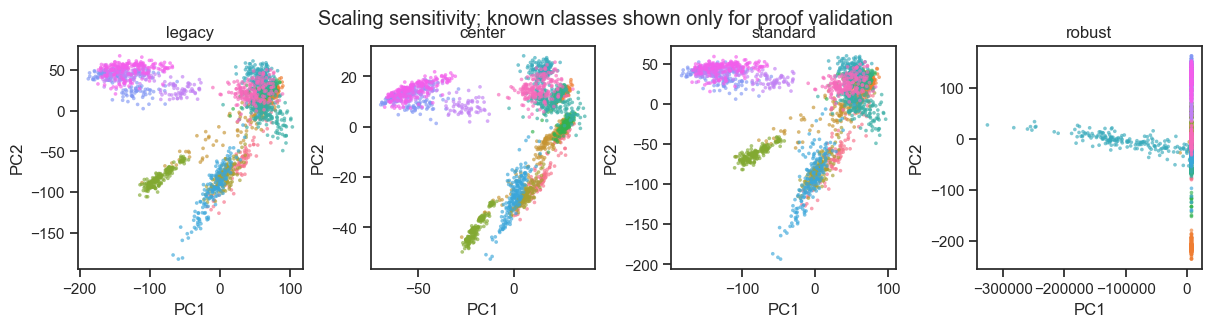

In [2]:
recipes = {}
for recipe in ('legacy', 'center', 'standard', 'robust'):
    with np.load(RESULTS / 'proof_p90' / f'{recipe}.npz', allow_pickle=True) as archive:
        recipes[recipe] = {key: archive[key] for key in archive.files}

fig, axes = plt.subplots(1, 4, figsize=(12, 3), constrained_layout=True)
for ax, recipe in zip(axes, recipes):
    payload = recipes[recipe]
    labels = payload['query_class'].astype(str)
    coordinates = payload['query_pca'][:, :2]
    sns.scatterplot(x=coordinates[:, 0], y=coordinates[:, 1], hue=labels,
                    s=7, linewidth=0, alpha=.65, legend=False, ax=ax)
    ax.set(title=recipe, xlabel='PC1', ylabel='PC2')
fig.suptitle('Scaling sensitivity; known classes shown only for proof validation', y=1.04)
plt.show()

## PCA, UMAP and t-SNE

PCA and UMAP below use the frozen development-fitted centre-only representation.
t-SNE has no stable out-of-sample transform, so its confirmation map is explicitly
transductive and illustrative. Neither UMAP nor t-SNE is used to fit clusters.

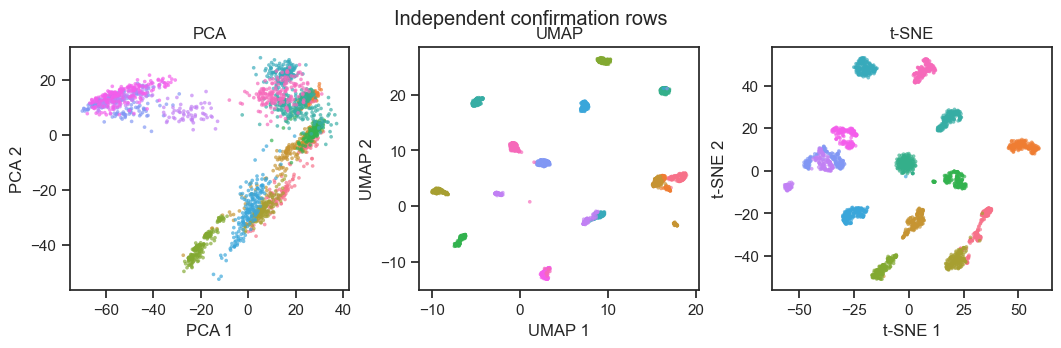

In [3]:
center = recipes['center']
coordinates_path = ROOT / 'results' / 'cross_mt_transfer_260824' / 'confirmation-coordinates.npz'
with np.load(coordinates_path, allow_pickle=True) as archive:
    umap_coordinates = archive['confirmation_umap_sym']
tsne_coordinates = TSNE(n_components=2, perplexity=50, init='pca',
                         learning_rate='auto', max_iter=1500,
                         random_state=260824).fit_transform(center['query_pca'])
views = [('PCA', center['query_pca'][:, :2]), ('UMAP', umap_coordinates), ('t-SNE', tsne_coordinates)]
labels = center['query_class'].astype(str)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)
for ax, (name, coordinates) in zip(axes, views):
    sns.scatterplot(x=coordinates[:, 0], y=coordinates[:, 1], hue=labels,
                    s=7, linewidth=0, alpha=.68, legend=False, ax=ax)
    ax.set(title=name, xlabel=f'{name} 1', ylabel=f'{name} 2')
fig.suptitle('Independent confirmation rows', y=1.04)
plt.show()

## Historical UMAP recipe

The original proof used $n_{\mathrm{neighbors}}=9$ and
$\mathrm{min\_dist}=0.75$. Here it is applied to the legacy PCA50 coordinates
rather than all retained features; the exact all-feature reproduction remains
available through `scripts/legacy_compat/proof_of_principle.py`. The PCA step makes
the notebook tractable and is the only deliberate deviation.

/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


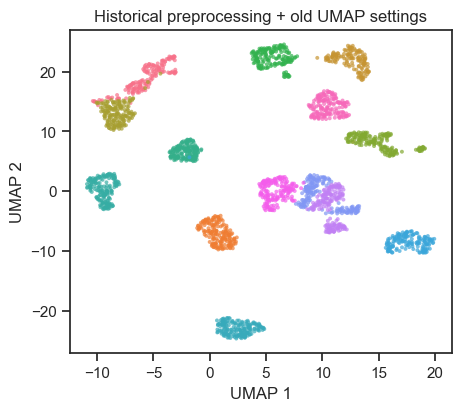

In [4]:
legacy = recipes['legacy']
legacy_umap = UMAP(n_neighbors=9, min_dist=.75, random_state=42, n_jobs=1).fit_transform(legacy['query_pca'])
fig, ax = plt.subplots(figsize=(4.5, 4), constrained_layout=True)
sns.scatterplot(x=legacy_umap[:, 0], y=legacy_umap[:, 1],
                hue=legacy['query_class'].astype(str), s=8, linewidth=0,
                alpha=.7, legend=False, ax=ax)
ax.set(title='Historical preprocessing + old UMAP settings', xlabel='UMAP 1', ylabel='UMAP 2')
plt.show()

## Live point-to-MTS browser

In [5]:
from src.corpus_visualization import interactive_embedding_browser

CONFIRMATION_FEATURES = ROOT / 'data' / 'proof_p90_260824' / 'features' / 'confirmation.npz'
RAW_ROOT = ROOT / 'data' / 'proof_p90_260824' / 'raw' / 'confirmation'
REMOTE_ROOT = Path('/g/data/ql44/we2614/mts-spi-data-v2/embeddings/cross_mt_confirmation_260824')
with np.load(CONFIRMATION_FEATURES, allow_pickle=True) as archive:
    remote_paths = archive['dataset_paths'].astype(str)
path_by_row = dict(zip(center['query_names'].astype(str), remote_paths))

def launch_proof_browser():
    def load_row(name):
        relative = Path(path_by_row[name]).relative_to(REMOTE_ROOT)
        return np.load(RAW_ROOT / relative / 'timeseries.npy')
    return interactive_embedding_browser(
        umap_coordinates,
        center['query_names'],
        load_row,
        title='Click a confirmation row to inspect its raw MTS',
        scaling='zscore',
    )

print('Run launch_proof_browser() in a live kernel to activate point-to-MTS selection.')

Run launch_proof_browser() in a live kernel to activate point-to-MTS selection.
